# 🧠 Deep Learning Practical Assignment (Adult Income Dataset)

## 📌 Dataset
We will use the **Adult Income dataset** (also known as the Census Income dataset).  
The task is to predict whether a person earns **more than $50K/year** based on demographic and employment attributes.

---


In [323]:
from sklearn.datasets import fetch_openml
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import category_encoders as ce
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Input
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
import warnings 
warnings.filterwarnings('ignore')

In [324]:
# Option 1: Using OpenML via scikit-learn


# Load dataset from OpenML
adult = fetch_openml(name="adult", version=2, as_frame=True)
df = adult.frame

print(df.head())
print(df.shape)  # (48842, 15)

# Separate features and target
X = df.drop(columns="class")
y = df["class"]


   age  workclass  fnlwgt     education  education-num      marital-status  \
0   25    Private  226802          11th              7       Never-married   
1   38    Private   89814       HS-grad              9  Married-civ-spouse   
2   28  Local-gov  336951    Assoc-acdm             12  Married-civ-spouse   
3   44    Private  160323  Some-college             10  Married-civ-spouse   
4   18        NaN  103497  Some-college             10       Never-married   

          occupation relationship   race     sex  capital-gain  capital-loss  \
0  Machine-op-inspct    Own-child  Black    Male             0             0   
1    Farming-fishing      Husband  White    Male             0             0   
2    Protective-serv      Husband  White    Male             0             0   
3  Machine-op-inspct      Husband  Black    Male          7688             0   
4                NaN    Own-child  White  Female             0             0   

   hours-per-week native-country  class  
0       

## Part 0: Data Preparation
1. Load the dataset into a DataFrame.
2. Split the data into **training, validation, and test sets**.  
   - Suggested: 70% training, 15% validation, 15% test.
3. Apply any necessary preprocessing:
   - Handle categorical features (encoding).
   - Scale numerical features if needed.
4. After training your models, always report results on:
   - **Training accuracy**
   - **Validation accuracy**
   - **Test accuracy**
5. At the end of the assignment, **compare all methods** across train, validation, and test sets.


In [325]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


In [326]:
y.head()

0    <=50K
1    <=50K
2     >50K
3     >50K
4    <=50K
Name: class, dtype: category
Categories (2, object): ['<=50K', '>50K']

Text(0.5, 0, 'Target')

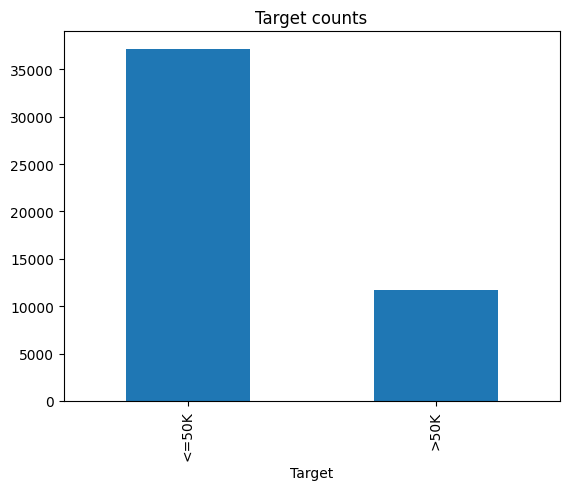

In [327]:
y.value_counts().plot(kind='bar')
plt.title("Target counts")
plt.xlabel("Target")

In [328]:
y.nunique()

2

In [329]:
X.isna().sum()

age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
dtype: int64

In [330]:
X.shape

(48842, 14)

In [331]:
X['education'].nunique()

16

In [332]:
X['workclass'].nunique()

8

In [333]:
X['native-country'].nunique()

41

In [334]:
from sklearn.impute import KNNImputer

# Columns to impute
cols = ['workclass', 'occupation', 'native-country']

# Step 1: Convert categories to numbers
encoders = {}
for col in cols:
    le = LabelEncoder()
    # Fit only on non-missing values
    le.fit(X[col].dropna())
    encoders[col] = le
    # Convert to numbers (missing values stay as NaN)
    X[col] = X[col].map(lambda x: le.transform([x])[0] if pd.notna(x) else x)

# Step 2: Apply KNN imputation
imputer = KNNImputer(n_neighbors=3)
X[cols] = imputer.fit_transform(X[cols])

for col in cols:
    X[col] = X[col].round()
    X[col] = X[col].clip(0, len(encoders[col].classes_) - 1).astype(int)
    X[col] = encoders[col].inverse_transform(X[col].to_numpy())
    X[col] = pd.Categorical(X[col], categories=encoders[col].classes_)



In [335]:
X.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
dtype: int64

In [336]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,Federal-gov,103497,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,30,United-States


In [337]:
X.describe(include='number')

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [338]:
X.describe(include='category')

,workclass,education,marital-status,occupation,relationship,race,sex,native-country
count,48842,48842,48842,48842,48842,48842,48842,48842
unique,8,16,7,14,6,5,2,41
top,Private,HS-grad,Married-civ-spouse,Adm-clerical,Husband,White,Male,United-States
freq,33906,15784,22379,8420,19716,41762,32650,43832


In [339]:
print(X['education'].nunique())
print(X['workclass'].nunique())
print(X['native-country'].nunique())


16
8
41


In [340]:
X.duplicated().sum()

57

In [341]:

indices_to_keep = X.index[~X.duplicated()]
X.drop_duplicates(inplace=True)
y = y.loc[indices_to_keep]

In [342]:
X.shape

(48785, 14)

In [343]:
X.duplicated().sum()

0

In [344]:
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

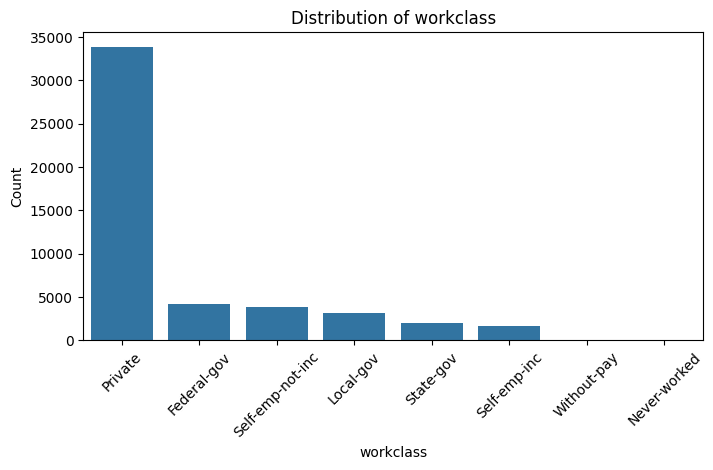

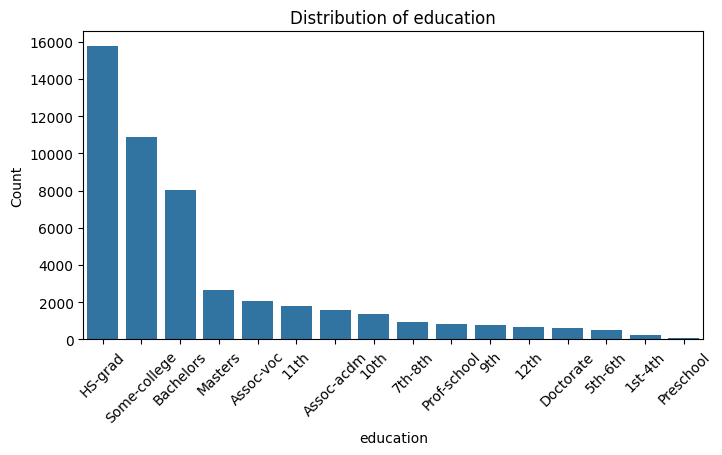

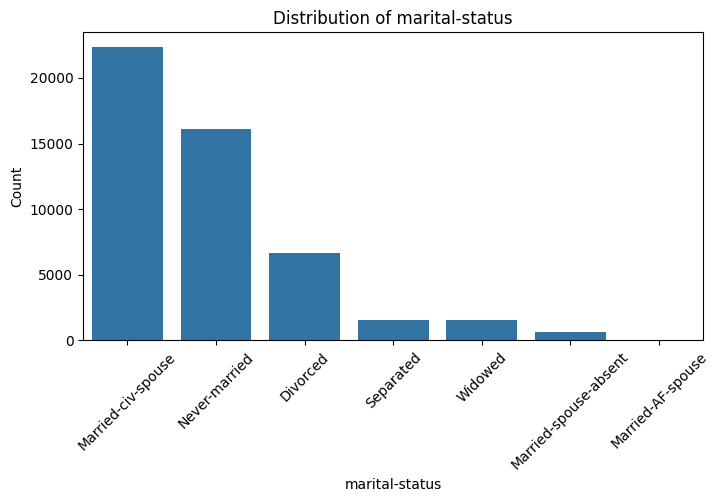

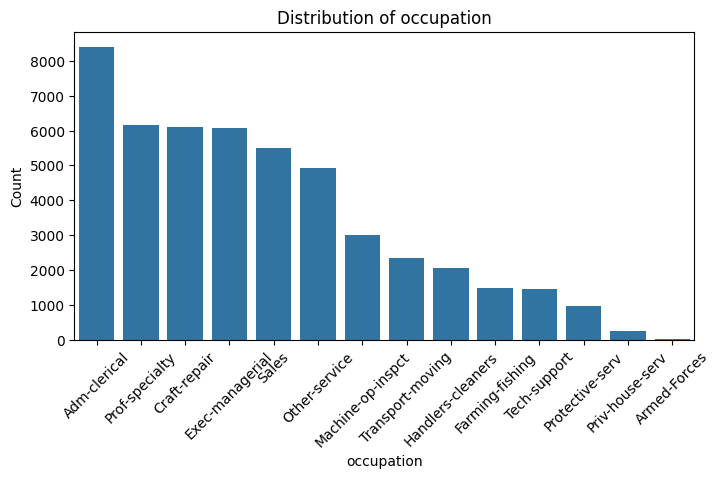

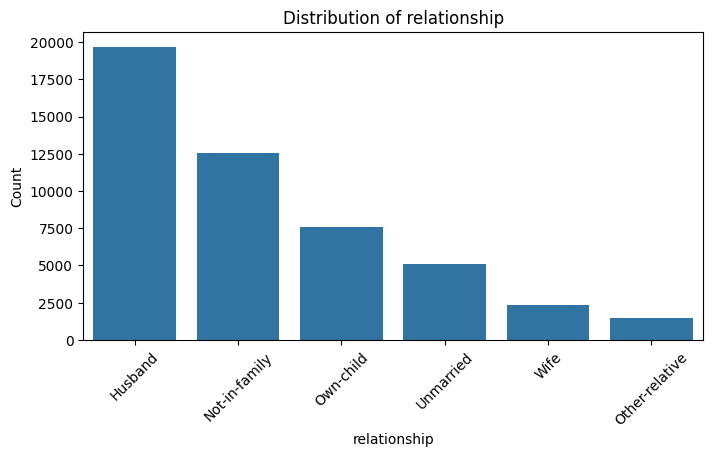

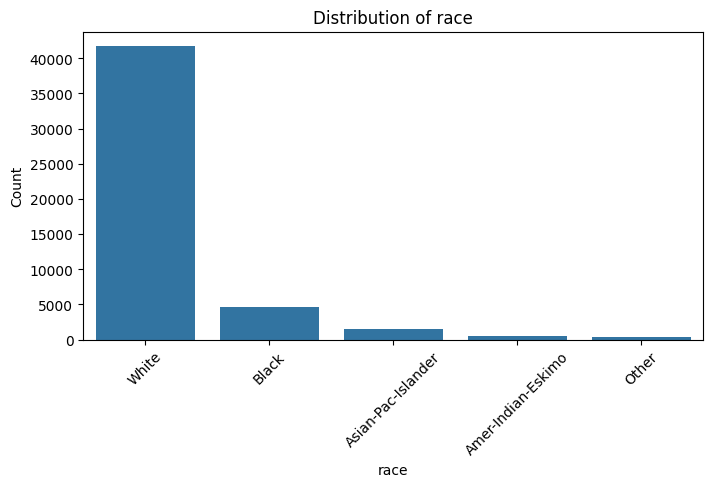

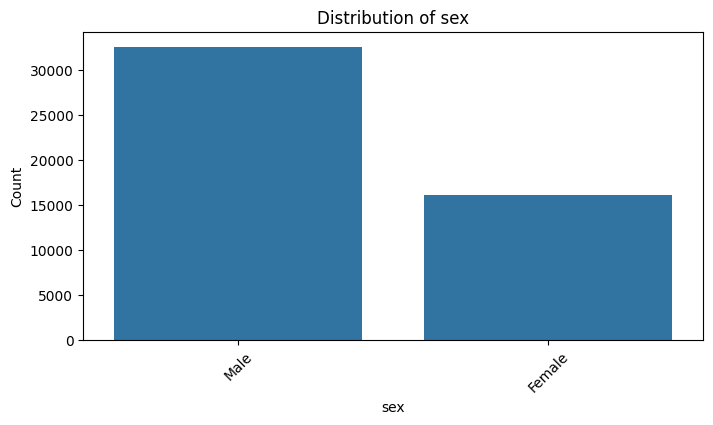

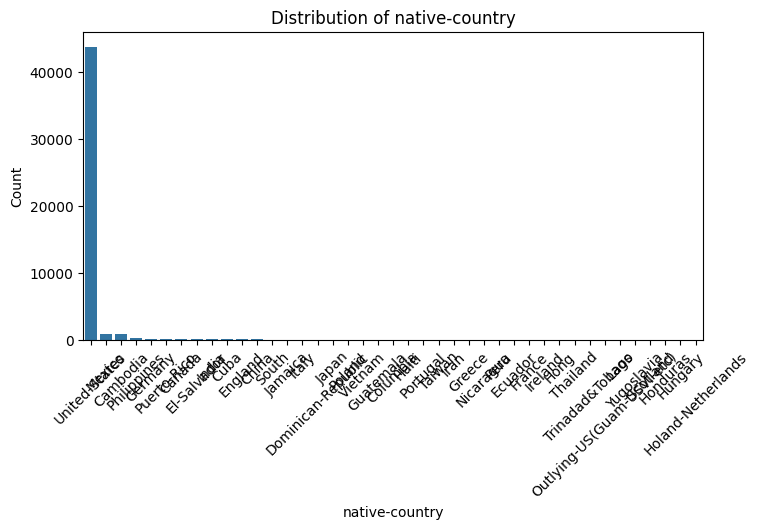

In [345]:
for col in categorical_features:
    plt.figure(figsize=(8,4))
    sns.countplot(data=X, x=col, order=X[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.ylabel("Count")
    plt.show()

In [346]:
value_counts = X['native-country'].value_counts()
rare_countries = value_counts[value_counts < 100].index
X['native-country'] = X['native-country'].replace(rare_countries, "Other")


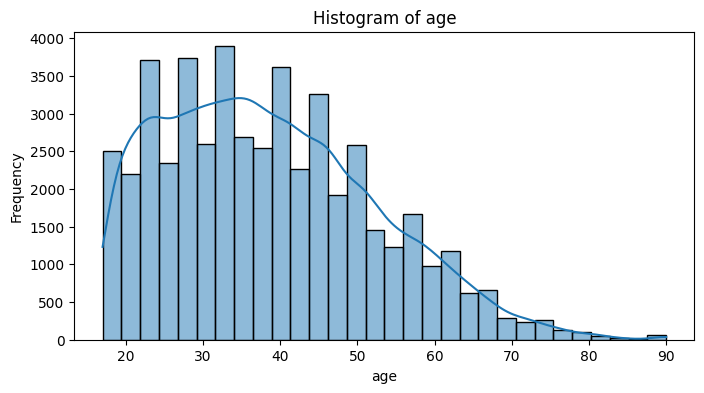

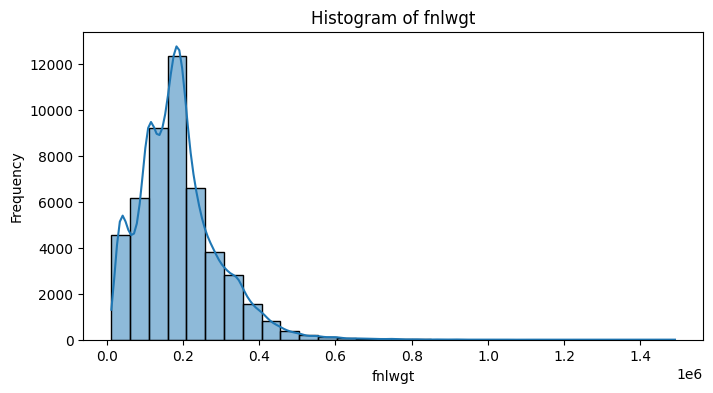

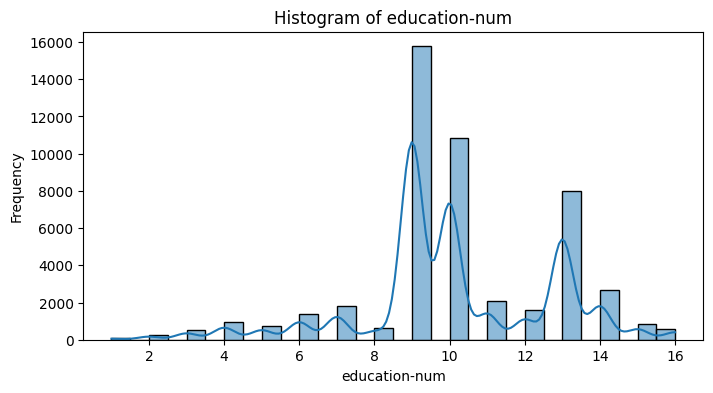

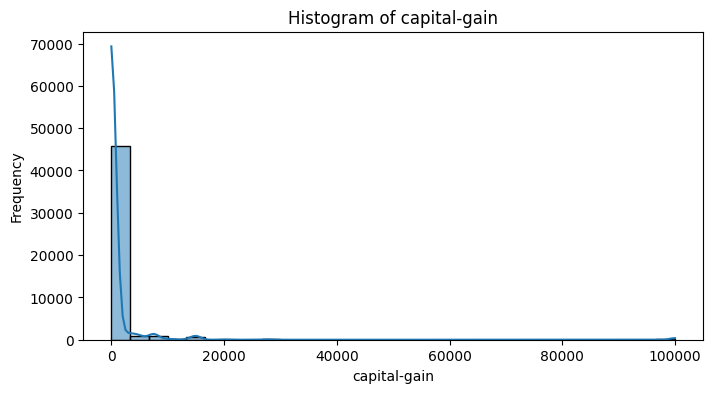

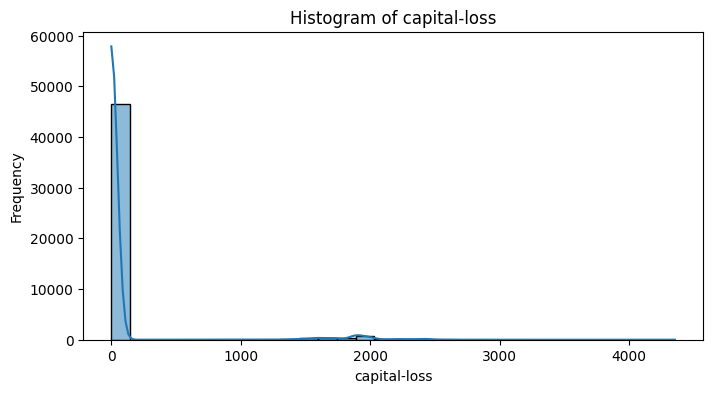

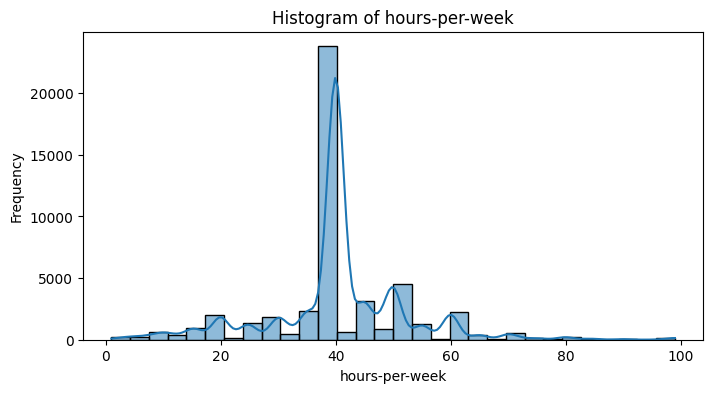

In [347]:
for col in numerical_features:
    plt.figure(figsize=(8,4))
    sns.histplot(X[col], bins=30, kde=True)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

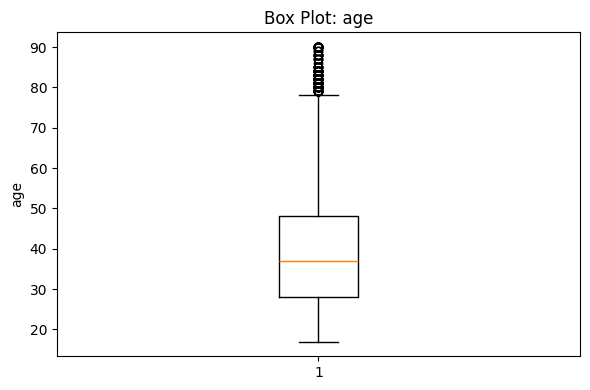

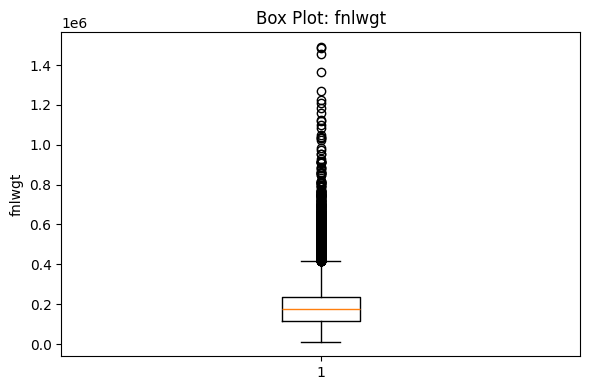

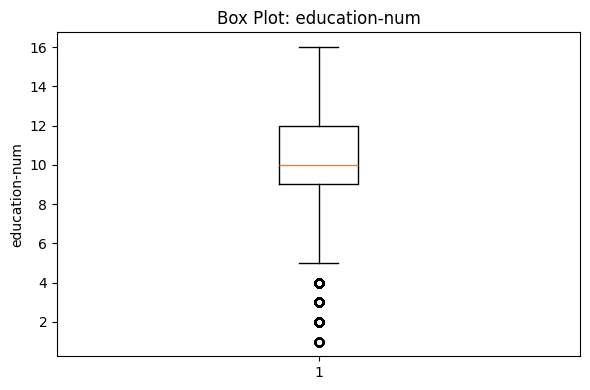

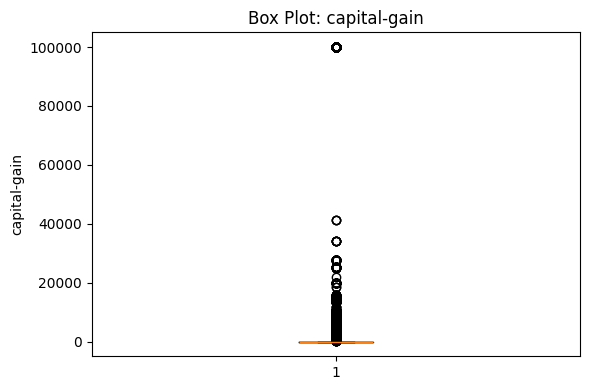

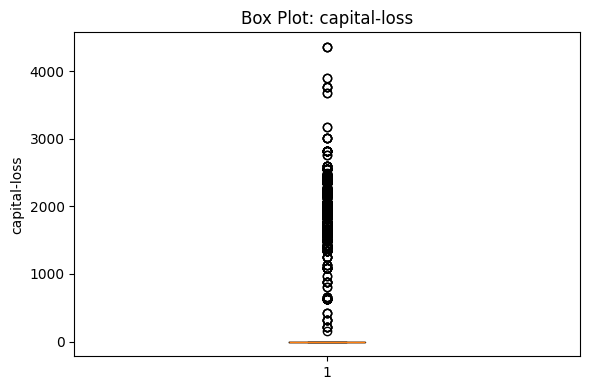

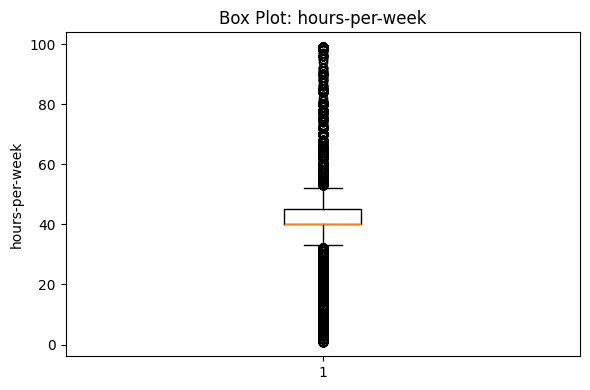

In [348]:
for col in numerical_features :
    plt.figure(figsize=(6, 4))
    plt.boxplot(X[col], vert=True, showfliers=True)
    plt.title(f"Box Plot: {col}")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

In [349]:
y = le.fit_transform(y)

In [350]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=
    
    42
)

In [351]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import PowerTransformer, RobustScaler
import pandas as pd

class CustomScaler(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.power = PowerTransformer(method='yeo-johnson')
        self.robust = RobustScaler()
        self.cols = numerical_features
    def fit(self, X, y=None):
        # Fit transformers only on selected columns
        self.power.fit(X[self.cols])
        self.robust.fit(self.power.transform(X[self.cols]))
        return self

    def transform(self, X):
        X_copy = X.copy()
        
        # Apply power transform
        transformed = self.power.transform(X_copy[self.cols])
        # Apply robust scaling
        transformed = self.robust.transform(transformed)

        # Reconstruct DataFrame with same column names & index
        X_copy[self.cols] = pd.DataFrame(
            transformed,
            columns=self.cols,
            index=X_copy.index
        )

        return X_copy


In [352]:
scaler = CustomScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_val = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


In [353]:
binary_features = ['marital-status', 'relationship', 'sex']
medium_features = ['occupation', 'race','workclass']
high_feature = ['native-country']
education_order = [
    "Preschool",
    "1st-4th",
    "5th-6th",
    "7th-8th",
    "9th",
    "10th",
    "11th",
    "12th",
    "HS-grad",
    "Some-college",
    "Assoc-voc",
    "Assoc-acdm",
    "Bachelors",
    "Masters",
    "Prof-school",
    "Doctorate"
]

education_mapping = {level: i for i, level in enumerate(education_order)}
X_train['education'] = X_train['education'].str.strip()
X_val['education']   = X_val['education'].str.strip()
X_test['education']  = X_test['education'].str.strip()

X_train['education'] = X_train['education'].map(education_mapping)
X_val['education'] = X_val['education'].map(education_mapping)
X_test['education'] = X_test['education'].map(education_mapping)

binary_encoders = {col: LabelEncoder() for col in binary_features}
count_encoder = ce.CountEncoder(normalize=True,cols=medium_features)
target_encoder = ce.TargetEncoder(cols=high_feature)

for col in binary_features:
    X_train[col] = binary_encoders[col].fit_transform(X_train[col])
    X_val[col]   = binary_encoders[col].transform(X_val[col])
    X_test[col]  = binary_encoders[col].transform(X_test[col])

X_train[medium_features] = count_encoder.fit_transform(X_train[medium_features])
X_val[medium_features]   = count_encoder.transform(X_val[medium_features])
X_test[medium_features]  = count_encoder.transform(X_test[medium_features])

X_train[high_feature] = target_encoder.fit_transform(X_train[high_feature], y_train)
X_val[high_feature]   = target_encoder.transform(X_val[high_feature])
X_test[high_feature]  = target_encoder.transform(X_test[high_feature])


In [354]:
X_val

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
32832,-0.504281,0.694193,-1.661959,9,0.000000,0,0.111951,4,0.854520,0,0.000000,0.000000,1.000000,0.244744
11736,-0.568085,0.694193,-0.252965,8,-0.322382,2,0.049020,0,0.854520,1,0.000000,0.000000,3.995781,0.244744
35820,-0.996527,0.065243,0.273115,7,-0.632928,4,0.041465,4,0.095523,0,0.000000,0.000000,-4.009834,0.244744
9998,-0.323271,0.694193,0.517484,6,-0.930828,2,0.020176,0,0.854520,1,0.000000,0.000000,0.000000,0.244744
12515,-1.340017,0.694193,-1.749887,6,-0.930828,4,0.101350,3,0.854520,1,0.000000,0.000000,0.000000,0.244744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14748,-0.381978,0.079505,-0.680744,12,1.031744,2,0.111951,0,0.854520,1,0.000000,0.000000,1.999250,0.244744
34648,1.257952,0.079505,-0.332177,9,0.000000,2,0.030572,0,0.854520,1,3.653229,0.000000,5.990048,0.244744
42394,0.973834,0.033412,-0.048626,8,-0.322382,2,0.125128,0,0.854520,1,3.653234,0.000000,1.000000,0.244744
10395,0.370543,0.694193,-0.079264,8,-0.322382,2,0.049020,0,0.854520,1,0.000000,0.000000,0.400095,0.244744


In [355]:
X_train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
37432,1.039802,0.033412,-0.627467,5,-1.215108,2,0.030572,0,0.854520,1,0.000000,0.0,1.999250,0.244744
25953,0.000000,0.041407,0.113588,12,1.031744,4,0.172157,1,0.854520,0,3.653280,0.0,0.000000,0.244744
29220,0.653060,0.033412,-1.451899,9,0.000000,2,0.172157,5,0.854520,0,0.000000,0.0,0.000000,0.244744
17324,0.327307,0.694193,-0.089374,12,1.031744,2,0.125128,0,0.854520,1,3.653278,0.0,3.995781,0.244744
25889,0.145946,0.694193,-0.706168,8,-0.322382,2,0.111951,5,0.854520,0,0.000000,0.0,-2.002648,0.244744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10062,0.800815,0.065243,0.456376,8,-0.322382,6,0.172157,1,0.854520,0,0.000000,0.0,0.000000,0.244744
43076,1.227915,0.033412,-0.657546,13,1.395452,2,0.125128,0,0.854520,1,3.653274,0.0,0.000000,0.244744
19490,0.906070,0.694193,-0.755619,8,-0.322382,6,0.126036,1,0.854520,0,0.000000,0.0,-4.411982,0.244744
35299,0.536029,0.079505,0.479458,8,-0.322382,0,0.101350,4,0.854520,0,0.000000,0.0,0.000000,0.244744


In [356]:
X_test

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
37450,0.495719,0.694193,-0.556838,8,-0.322382,6,0.172157,1,0.85452,0,0.0,0.000000,-1.601801,0.244744
25237,0.836401,0.079505,0.121650,8,-0.322382,2,0.030572,0,0.85452,1,0.0,0.000000,6.388660,0.244744
11698,-0.050781,0.694193,1.173920,5,-1.215108,5,0.111951,1,0.85452,1,0.0,0.000000,0.000000,0.244744
27536,-0.381978,0.694193,-0.937005,9,0.000000,2,0.126153,0,0.85452,1,0.0,4.744758,0.000000,0.244744
7512,0.098314,0.694193,-0.585340,9,0.000000,2,0.125128,0,0.85452,1,0.0,0.000000,2.997823,0.244744
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
526,-0.050781,0.694193,-1.662828,12,1.031744,2,0.125128,0,0.85452,1,0.0,0.000000,0.000000,0.244744
24035,-1.248608,0.694193,1.632508,6,-0.930828,4,0.111951,3,0.85452,0,0.0,0.000000,-6.427974,0.042836
20627,0.728055,0.694193,-0.734951,8,-0.322382,4,0.172157,4,0.85452,0,0.0,0.000000,0.000000,0.244744
20578,-0.155866,0.065243,0.469133,13,1.395452,2,0.125128,0,0.85452,1,0.0,0.000000,0.000000,0.244744



## Part 1: Optimizers
1. Train the same neural network using:
   - Stochastic Gradient Descent (SGD)
   - SGD with Momentum
   - Adam
2. Compare the training and validation accuracy for each optimizer.
3. Which optimizer converges the fastest? Which gives the best generalization?
4. Explain *why* Adam often performs better than plain SGD.

---


#### **Adam** Coverage faster with high accuracy beacuse It's adapts the learning rate for each parameter individually, which allows for faster and more efficient convergence while SGD gives gives all the parameters the same learning rate and momentom speed coverage by adding speed parameter


## Without early stopping it go to overfittting with it it stps at 4 epoches


In [357]:

def build_model(input_dim):
    model = Sequential([
        Dense(64, activation='relu', input_shape=(input_dim,)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')  
    ])
    return model

# Build model once for each optimizer
optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "SGD+Momentum": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    "Adam": tf.keras.optimizers.Adam()
}

histories = {}

for name, opt in optimizers.items():
    model = build_model(X_train.shape[1])

    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])

    print(f"Training with {name}...")

    # early_stopping = EarlyStopping(monitor='val_loss', patience=3,min_delta=0.1, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=20,
        # callbacks=[early_stopping]
        
    )
    histories[name] = history
    print(f"Training completed after with {name} at {len(history.epoch)} epochs.")




Training with SGD...
Epoch 1/20


1068/1068 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8004 - loss: 0.4351 - val_accuracy: 0.7924 - val_loss: 0.4450
Epoch 2/20
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8220 - loss: 0.3880 - val_accuracy: 0.8296 - val_loss: 0.3723
Epoch 3/20
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8248 - loss: 0.3727 - val_accuracy: 0.8356 - val_loss: 0.3647
Epoch 4/20
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8294 - loss: 0.3624 - val_accuracy: 0.8075 - val_loss: 0.4095
Epoch 5/20
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8331 - loss: 0.3552 - val_accuracy: 0.8370 - val_loss: 0.3496
Epoch 6/20
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8335 - loss: 0.3529 - val_accuracy: 0.8397 - val_loss: 0.3440
Epoch 7/20
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8339 - loss: 0.3497 - val_accuracy: 0.8389 - val_loss: 0.3403
Epoch 8/20
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8336 - loss: 0.3478 - val_accurac

## Adam with the most accuracy and less loss but it overfit

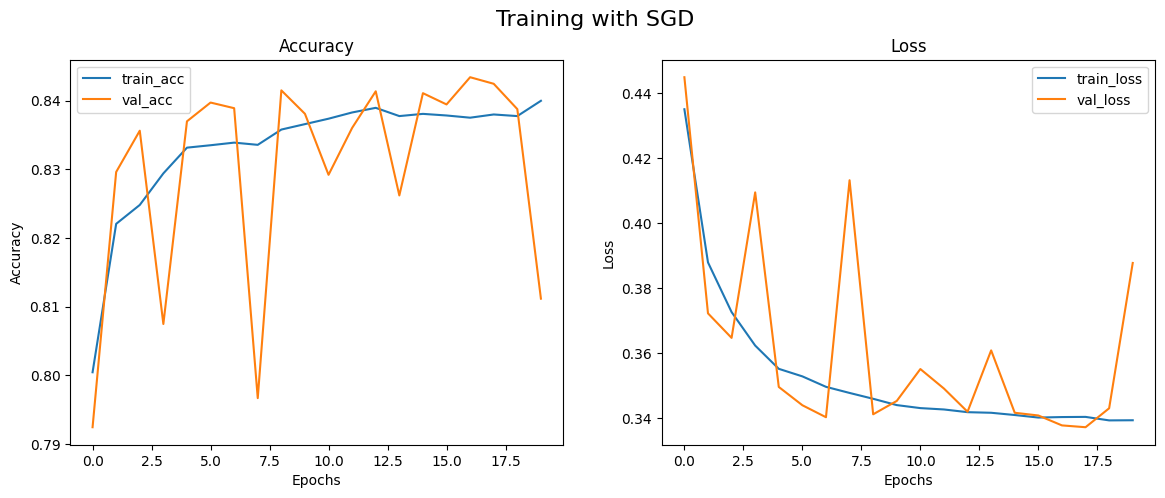

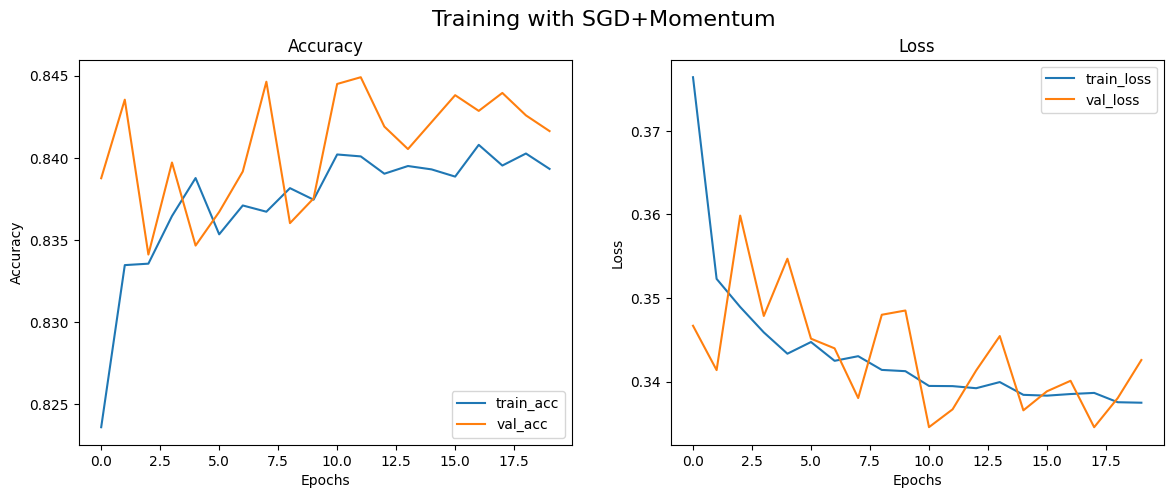

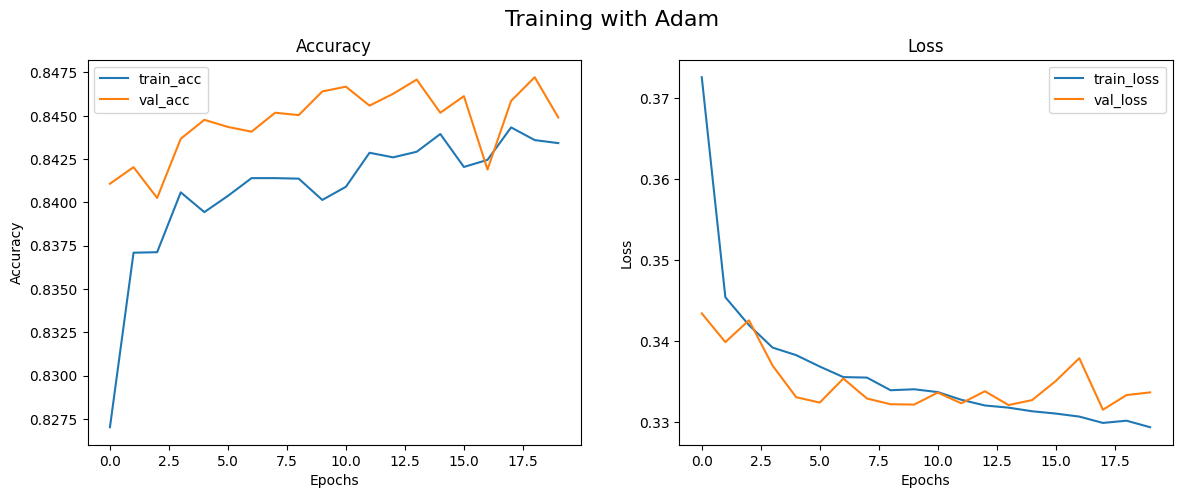

In [358]:
import matplotlib.pyplot as plt

for name, history in histories.items():
    # Create a figure for each optimizer
    fig, axs = plt.subplots(1, 2, figsize=(14,5))
    fig.suptitle(f"Training with {name}", fontsize=16)

    # --- Accuracy plot ---
    axs[0].plot(history.history['accuracy'], label='train_acc')
    axs[0].plot(history.history['val_accuracy'], label='val_acc')
    axs[0].set_title("Accuracy")
    axs[0].set_xlabel("Epochs")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend()

    # --- Loss plot ---
    axs[1].plot(history.history['loss'], label='train_loss')
    axs[1].plot(history.history['val_loss'], label='val_loss')
    axs[1].set_title("Loss")
    axs[1].set_xlabel("Epochs")
    axs[1].set_ylabel("Loss")
    axs[1].legend()

    plt.show()


## Part 2: Batch Size
1. Train the same model with different batch sizes (e.g., 1, 32, 128, 1024).
2. Compare:
   - Training speed
   - Validation accuracy
   - Test accuracy
   - Generalization ability
3. Which batch size leads to the **noisiest gradient updates**?
4. Which batch size generalizes better and why?

In [368]:
batch_sizes = [1, 32,64, 128, 1024]
results_batch = {}

for batch in batch_sizes:
    print(f"\n=== Training with batch size = {batch} ===")
    model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation="relu"),
        Dense(32, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer='adam',
                  loss="binary_crossentropy",
                  metrics=["accuracy"])

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=5,
        batch_size=batch    )

    results_batch[batch] = history.history



=== Training with batch size = 1 ===
Epoch 1/5
34149/34149 ━━━━━━━━━━━━━━━━━━━━ 102s 3ms/step - accuracy: 0.8299 - loss: 0.3626 - val_accuracy: 0.8393 - val_loss: 0.3474
Epoch 2/5
34149/34149 ━━━━━━━━━━━━━━━━━━━━ 100s 3ms/step - accuracy: 0.8367 - loss: 0.3481 - val_accuracy: 0.8409 - val_loss: 0.3393
Epoch 3/5
34149/34149 ━━━━━━━━━━━━━━━━━━━━ 159s 3ms/step - accuracy: 0.8378 - loss: 0.3456 - val_accuracy: 0.8452 - val_loss: 0.3413
Epoch 4/5
34149/34149 ━━━━━━━━━━━━━━━━━━━━ 113s 3ms/step - accuracy: 0.8378 - loss: 0.3435 - val_accuracy: 0.8409 - val_loss: 0.3400
Epoch 5/5
34149/34149 ━━━━━━━━━━━━━━━━━━━━ 102s 3ms/step - accuracy: 0.8395 - loss: 0.3431 - val_accuracy: 0.8375 - val_loss: 0.3421

=== Training with batch size = 32 ===
Epoch 1/5
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8213 - loss: 0.3808 - val_accuracy: 0.8433 - val_loss: 0.3398
Epoch 2/5
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8365 - loss: 0.3441 - val_accuracy: 0.8427 - val_loss: 0.3394


#### 3.Batch size 1 is the noiseist and the most time to run because from only 1 data point the model can't learn 
#### 4. batch size 32 and 128 are the best to not overfit and add noise and smooth and batch 1024 learns too fast and can't coverage

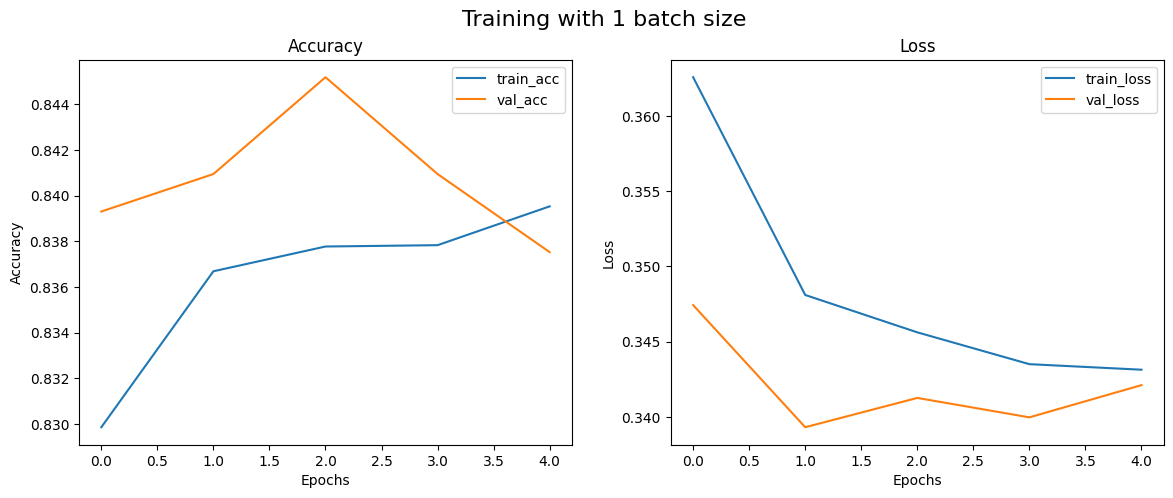

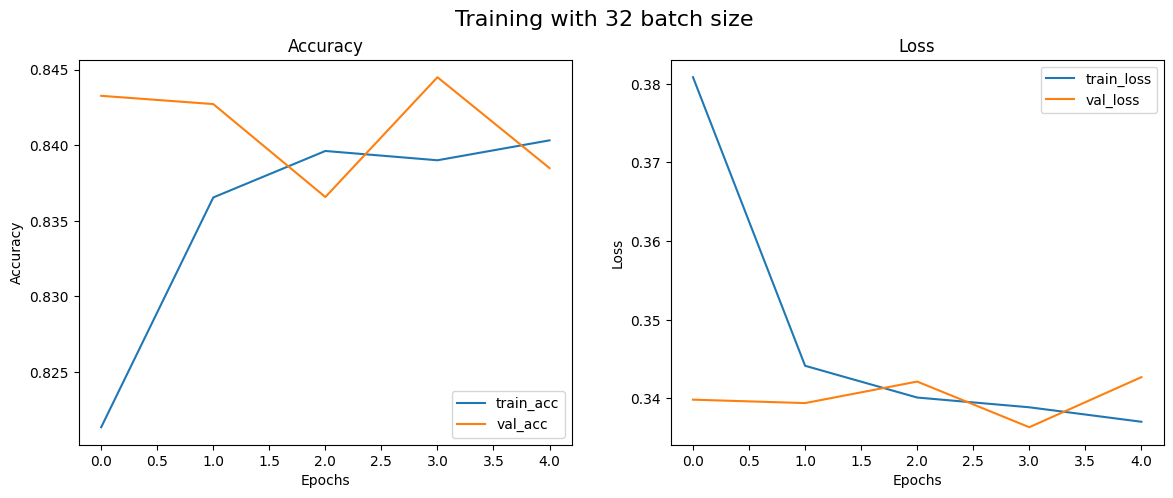

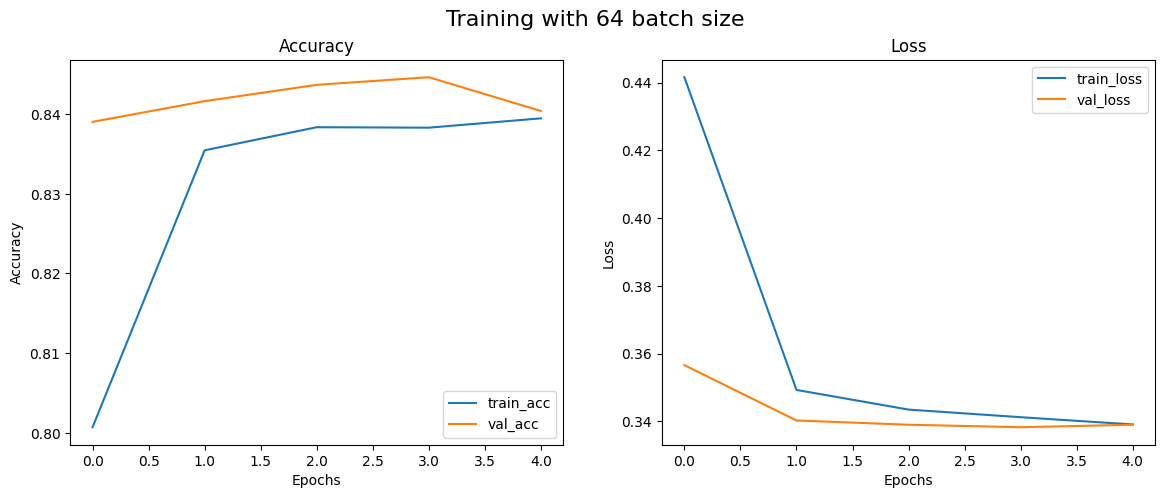

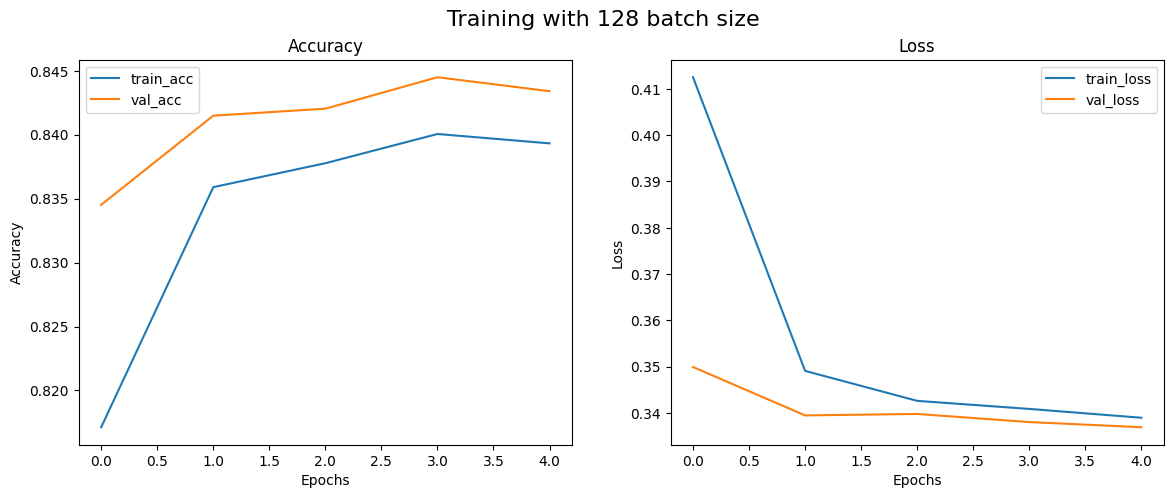

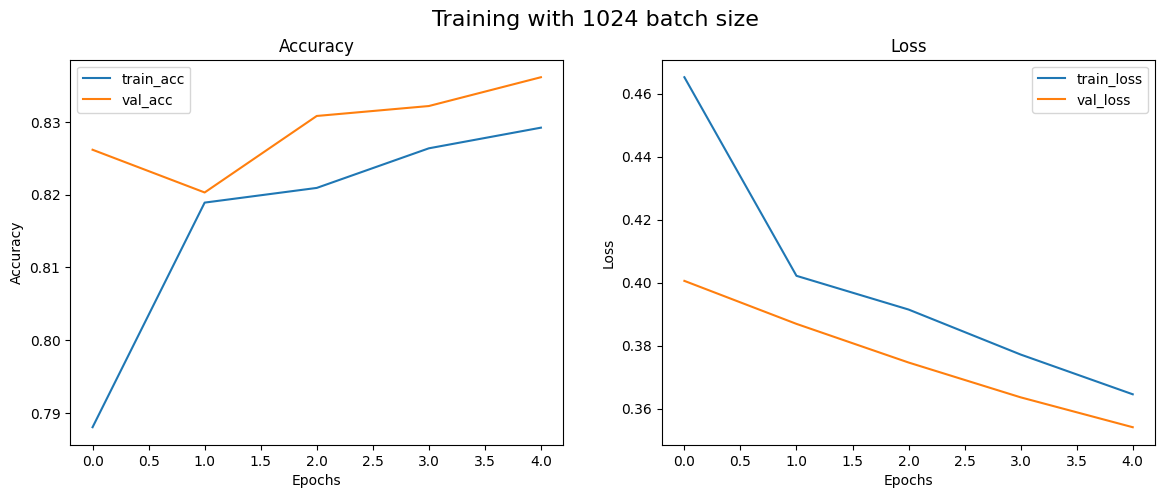

In [369]:
import matplotlib.pyplot as plt

for batch, history in results_batch.items():
    # Create a figure for each optimizer
    fig, axs = plt.subplots(1, 2, figsize=(14,5))
    fig.suptitle(f"Training with {batch} batch size", fontsize=16)

    # --- Accuracy plot ---
    axs[0].plot(history['accuracy'], label='train_acc')
    axs[0].plot(history['val_accuracy'], label='val_acc')
    axs[0].set_title("Accuracy")
    axs[0].set_xlabel("Epochs")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend()

    # --- Loss plot ---
    axs[1].plot(history['loss'], label='train_loss')
    axs[1].plot(history['val_loss'], label='val_loss')
    axs[1].set_title("Loss")
    axs[1].set_xlabel("Epochs")
    axs[1].set_ylabel("Loss")
    axs[1].legend()

    plt.show()



## Part 3: Overfitting and Regularization
1. Train a large neural network (many parameters) on the dataset.
2. Observe training vs. validation accuracy.  
   - Do you see signs of overfitting?
3. Apply regularization techniques:
   - **L2 regularization**
   - **Dropout**
4. Compare the validation results before and after regularization.
5. Which regularization method was more effective in reducing overfitting? Why?

---


In [361]:
model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])
model.compile(optimizer='adam',
      loss="binary_crossentropy",
      metrics=["accuracy"])

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32    )


Epoch 1/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7719 - loss: 0.5376 - val_accuracy: 0.8303 - val_loss: 0.4059
Epoch 2/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8168 - loss: 0.4195 - val_accuracy: 0.8333 - val_loss: 0.3779
Epoch 3/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8256 - loss: 0.4007 - val_accuracy: 0.8374 - val_loss: 0.3658
Epoch 4/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8271 - loss: 0.3901 - val_accuracy: 0.8366 - val_loss: 0.3642
Epoch 5/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8270 - loss: 0.3851 - val_accuracy: 0.8405 - val_loss: 0.3557
Epoch 6/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8304 - loss: 0.3819 - val_accuracy: 0.8385 - val_loss: 0.3556
Epoch 7/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8291 - loss: 0.3790 - val_accuracy: 0.8409 - val_loss: 0.3552
Epoch 8/10
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8321 - loss: 0.3747 - 

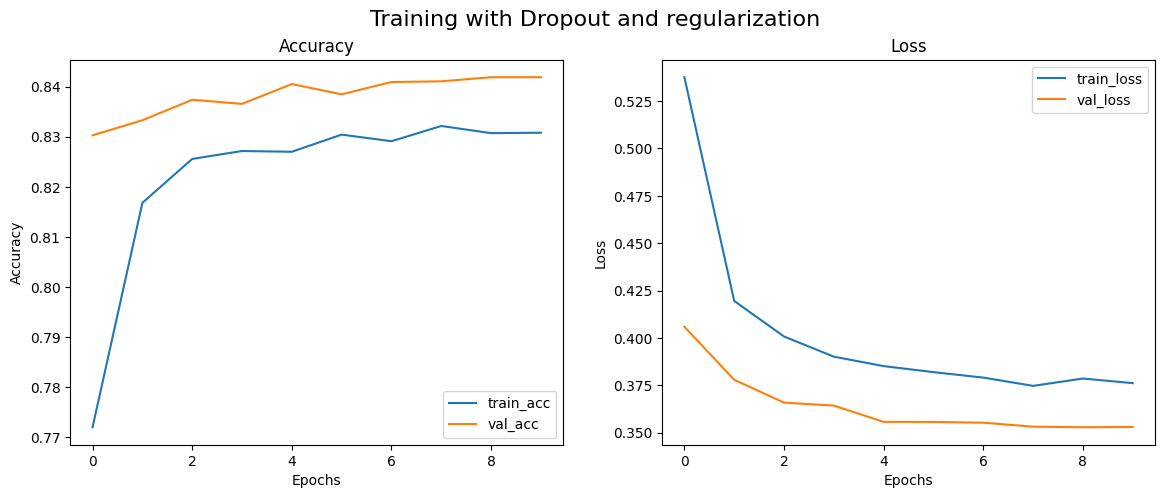

In [362]:
fig, axs = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle(f"Training with Dropout and regularization", fontsize=16)

# --- Accuracy plot ---
axs[0].plot(history.history['accuracy'], label='train_acc')
axs[0].plot(history.history['val_accuracy'], label='val_acc')
axs[0].set_title("Accuracy")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Accuracy")
axs[0].legend()

# --- Loss plot ---
axs[1].plot(history.history['loss'], label='train_loss')
axs[1].plot(history.history['val_loss'], label='val_loss')
axs[1].set_title("Loss")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Loss")
axs[1].legend()
plt.show()

## Part 4: Early Stopping
1. Train the model for many epochs without early stopping.  
   - Plot training, validation, and test curves.
2. Train again with **early stopping** (monitor validation loss).
3. Compare the number of epochs trained and the final validation/test accuracy.
4. Explain how early stopping helps prevent overfitting.

---

In [363]:
model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])
model.compile(optimizer='adam',
      loss="binary_crossentropy",
      metrics=["accuracy"])

before_history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32    )


Epoch 1/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7697 - loss: 0.5343 - val_accuracy: 0.8286 - val_loss: 0.4110
Epoch 2/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8136 - loss: 0.4258 - val_accuracy: 0.8323 - val_loss: 0.3787
Epoch 3/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8222 - loss: 0.4014 - val_accuracy: 0.8397 - val_loss: 0.3639
Epoch 4/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8272 - loss: 0.3904 - val_accuracy: 0.8396 - val_loss: 0.3604
Epoch 5/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8295 - loss: 0.3830 - val_accuracy: 0.8411 - val_loss: 0.3556
Epoch 6/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8310 - loss: 0.3798 - val_accuracy: 0.8400 - val_loss: 0.3570
Epoch 7/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8299 - loss: 0.3776 - val_accuracy: 0.8397 - val_loss: 0.3531
Epoch 8/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8318 - loss: 0.3776 - 

In [364]:
model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])
model.compile(optimizer='adam',
      loss="binary_crossentropy",
      metrics=["accuracy"])
early_stopping = EarlyStopping(monitor='val_loss', patience=3,min_delta=0.1, restore_best_weights=True)


after_history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32  ,
    callbacks=[early_stopping]  )
print(f"Model stopped after {len(after_history.epoch)}")

Epoch 1/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7790 - loss: 0.5338 - val_accuracy: 0.8316 - val_loss: 0.4141
Epoch 2/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8170 - loss: 0.4259 - val_accuracy: 0.8377 - val_loss: 0.3774
Epoch 3/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8234 - loss: 0.4003 - val_accuracy: 0.8382 - val_loss: 0.3652
Epoch 4/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8280 - loss: 0.3878 - val_accuracy: 0.8385 - val_loss: 0.3626
Model stopped after 4


# Overfitting and the model used to this data

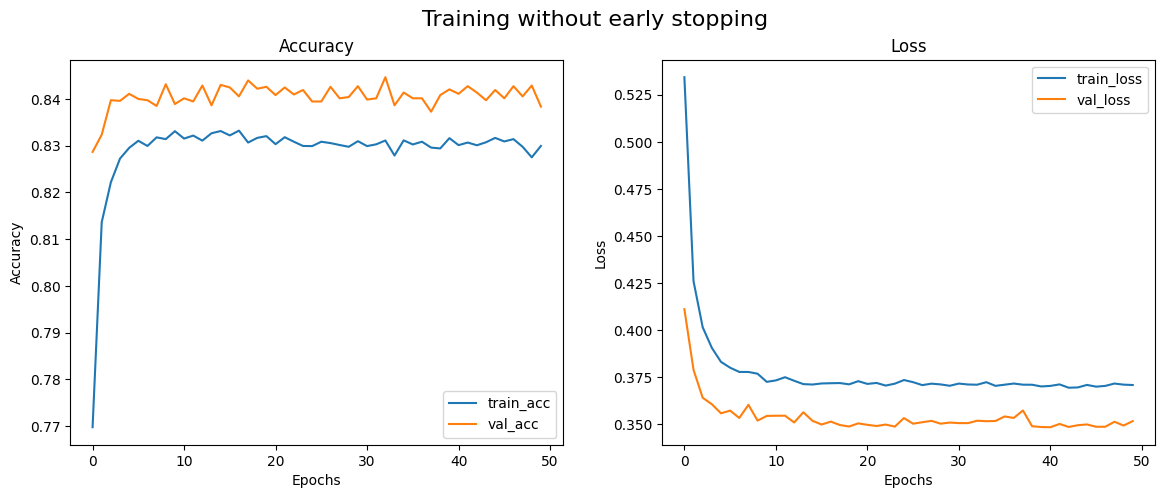

In [365]:
fig, axs = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle(f"Training without early stopping", fontsize=16)

# --- Accuracy plot ---
axs[0].plot(before_history.history['accuracy'], label='train_acc')
axs[0].plot(before_history.history['val_accuracy'], label='val_acc')
axs[0].set_title("Accuracy")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Accuracy")
axs[0].legend()

# --- Loss plot ---
axs[1].plot(before_history.history['loss'], label='train_loss')
axs[1].plot(before_history.history['val_loss'], label='val_loss')
axs[1].set_title("Loss")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Loss")
axs[1].legend()
plt.show()

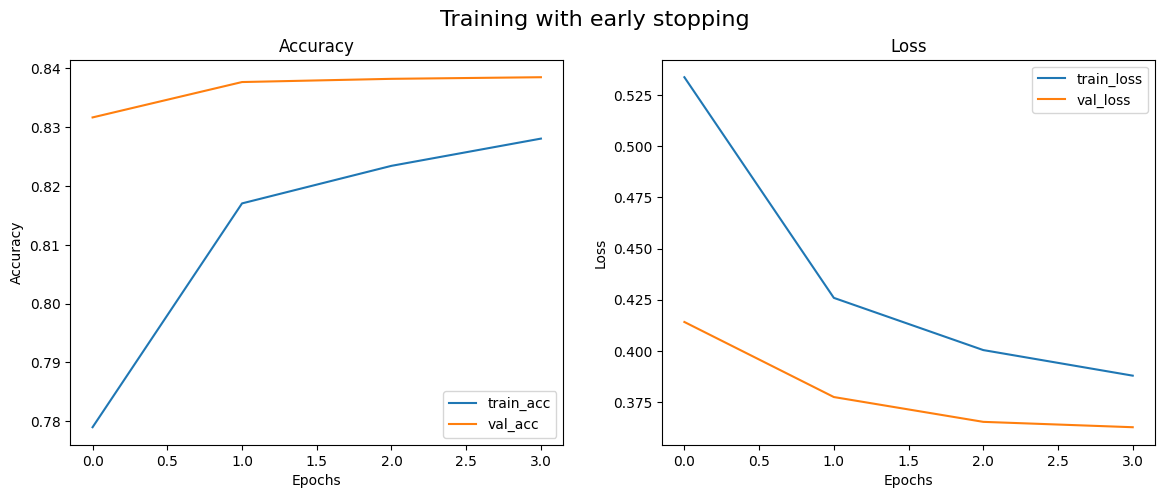

In [366]:
fig, axs = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle(f"Training with early stopping", fontsize=16)

# --- Accuracy plot ---
axs[0].plot(after_history.history['accuracy'], label='train_acc')
axs[0].plot(after_history.history['val_accuracy'], label='val_acc')
axs[0].set_title("Accuracy")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Accuracy")
axs[0].legend()

# --- Loss plot ---
axs[1].plot(after_history.history['loss'], label='train_loss')
axs[1].plot(after_history.history['val_loss'], label='val_loss')
axs[1].set_title("Loss")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Loss")
axs[1].legend()
plt.show()

In [367]:
best_model = Sequential([
        Input(shape=(X_train.shape[1],)),
        Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])
best_model.compile(optimizer='adam',
      loss="binary_crossentropy",
      metrics=["accuracy"])
early_stopping = EarlyStopping(monitor='val_loss', patience=3,min_delta=0.01, restore_best_weights=True)


history = best_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64  ,
    callbacks=[early_stopping]  )
print(f"Model stopped after {len(history.epoch)}")


loss, acc = best_model.evaluate(X_test, y_test)
print(f"Best model accuracy on test data: {acc:.3f}")
print(f"Best model loss on test data: {loss:.3f}")

Epoch 1/10
534/534 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7596 - loss: 0.5612 - val_accuracy: 0.8300 - val_loss: 0.4224
Epoch 2/10
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8110 - loss: 0.4330 - val_accuracy: 0.8341 - val_loss: 0.3818
Epoch 3/10
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8206 - loss: 0.4052 - val_accuracy: 0.8377 - val_loss: 0.3681
Epoch 4/10
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8268 - loss: 0.3955 - val_accuracy: 0.8404 - val_loss: 0.3637
Epoch 5/10
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8284 - loss: 0.3898 - val_accuracy: 0.8400 - val_loss: 0.3604
Epoch 6/10
534/534 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8299 - loss: 0.3835 - val_accuracy: 0.8412 - val_loss: 0.3558
Epoch 7/10
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8321 - loss: 0.3805 - val_accuracy: 0.8419 - val_loss: 0.3539
Epoch 8/10
534/534 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8323 - loss: 0.3761 - val_accuracy: 0.

## Part 5: Reflection
1. Summarize what you learned about:
   - The role of optimizers
   - The effect of batch size
   - Regularization methods
   - Early stopping
   - Train/validation/test splits
2. If you had to train a deep learning model on a new tabular dataset, what choices would you make for:
   - Optimizer
   - Batch size
   - Regularization
   - Early stopping
   - Data splitting strategy  
   and why?

# 1. 
## SGD updates weights with raw gradients and can be slow whiele Momentum helps accelerate learning by smoothing updates but Adam adapts the learning rate for each parameter and usually converges faster with better generalization, especially for noisy/tabular data 
## The batch size don't need to be low so it doesn't make noisy gradient or to big it wouldn't generlize
## regularization help the model not to overfit and to adapt to more patterns of the data 
## Early stopping stops the model when it stop performing and save effort and overfitting 
## Splitting important to not cause data leakage and the validation tunes the hyperparameters

# 2. Adam , 32,128,l2(.001),yes ,70 train 15 validation 15 test for small data for large ones 90 train 5 valiadation 5 test 